# Run on google colab only

This notebook is optimized for Google Colab AND GPU optimized devices using cuML library for faster SVM tuning and training

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ln -sf '/content/drive/MyDrive/svm_gridsearch' '/content/svm_gridsearch'

Mounted at /content/drive


In [2]:
!nvidia-smi

Mon Apr 13 02:27:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
%load_ext cuml.accel
%load_ext cudf.pandas

In [4]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.4 MB/s eta 0:00:00


# Define constants

In [5]:
CLEAN_FEATURES_PATH = "./svm_gridsearch/opus-clean.npz"
NOISY_FEATURES_PATH = "./svm_gridsearch/opus-noisy.npz"
MODEL_SAVE_PATH = "./models"
RANDOM_STATE = 42
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5
SVM_RANDOM_STATE = RANDOM_STATE

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
SVM_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, 'model.pkl')
SVM_SCALER_PATH = os.path.join(MODEL_SAVE_PATH, 'scaler.pkl')
SVM_ENCODER_PATH = os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Tuning & Training

## Load features

In [6]:
data = np.load(CLEAN_FEATURES_PATH)
features = data['features']
labels = data['labels']
print(f"Loaded features shape: {features.shape}")

Loaded features shape: (7200, 36, 200)


## Split data

In [7]:
from cuml.model_selection import train_test_split
from cuml.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Sample the dataset to half (50%) with balanced classes to speed up GridSearch
# features_sampled, _, labels_sampled, _ = train_test_split(
#     features_scaled,
#     svm_encoded_labels,
#     train_size=0.5,
#     random_state=SVM_RANDOM_STATE,
#     stratify=svm_encoded_labels
# )

# Train/test split on the sampled data
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    # features_sampled,
    # labels_sampled,
    features_scaled,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=SVM_RANDOM_STATE,
    stratify=svm_encoded_labels
    # stratify=labels_sampled
)

print(f"Original dataset size: {len(features_scaled)}")
# print(f"Sampled dataset size:   {len(features_sampled)}")
print(f"X_svm_train shape:      {X_svm_train.shape}")
print(f"X_svm_test shape:       {X_svm_test.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size: 7200
X_svm_train shape:      (6480, 7200)
X_svm_test shape:       (720, 7200)
Number of classes:      36


## Hyperparameter Tuning

Choose one of the three methods for tuning!

### Grid Search CV (Unused)

Params from (Putra & Sanjata, 2025). Tuning too slow

In [ ]:
from cuml.svm import SVC
import numpy as np

# Prepare data for cuML GridSearchCV
X_train_cpu = X_svm_train.get() if hasattr(X_svm_train, 'get') else np.array(X_svm_train)
if hasattr(y_svm_train, 'to_numpy'):
    y_train_cpu = y_svm_train.to_numpy()
elif hasattr(y_svm_train, 'get'):
    y_train_cpu = y_svm_train.get()
else:
    y_train_cpu = np.array(y_svm_train)

param_grid = {
    'kernel': ['rbf'],
    'C':      [0.1, 1, 10, 100, 1000],
    'gamma':  ['scale', 'auto', 0.01, 0.1, 0.5, 0.9],
}

# n_jobs=None is preferred for cuML to avoid CPU process management overhead
grid_search = GridSearchCV(
    SVC(random_state=SVM_RANDOM_STATE),
    param_grid,
    cv=SVM_CV_FOLDS,
    scoring='accuracy',
    verbose=3
)

print("Running full GPU-accelerated GridSearchCV...")
grid_search.fit(X_train_cpu, y_train_cpu)
print("Done.")

import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')[
    ['rank_test_score', 'param_C', 'param_kernel', 'param_gamma',
     'mean_test_score', 'std_test_score']
].rename(columns={
    'rank_test_score': 'Rank',
    'param_C': 'C',
    'param_kernel': 'Kernel',
    'param_gamma': 'Gamma',
    'mean_test_score': 'Mean CV Accuracy',
    'std_test_score': 'Std CV Accuracy',
})

cv_results_sorted.head(10)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_svm_model = grid_search.best_estimator_

### Optimized search from paper (UNUSED)

Based on https://arxiv.org/pdf/2008.11655 . Training too slow

In [ ]:
import optuna
import pandas as pd
import numpy as np
from cuml.svm import SVC
# Use sklearn's StratifiedKFold to avoid the 'groups' argument TypeError with cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_train_cpu = X_svm_train.get() if hasattr(X_svm_train, 'get') else np.array(X_svm_train)
if hasattr(y_svm_train, 'to_numpy'):
    y_train_cpu = y_svm_train.to_numpy()
elif hasattr(y_svm_train, 'get'):
    y_train_cpu = y_svm_train.get()
else:
    y_train_cpu = np.array(y_svm_train)

def objective(trial):
    # 1. Define the search space logarithmically
    c_val = trial.suggest_float("C", 1e-3, 1e3, log=True)
    gamma_val = trial.suggest_float("gamma", 1e-5, 1e-2, log=True)

    # 2. Instantiate the cuML model (GPU accelerated)
    model = SVC(kernel='rbf', C=c_val, gamma=gamma_val, random_state=42)

    # 3. Evaluate using robust cross-validation
    # Using sklearn's StratifiedKFold here fixes the compatibility error
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_cpu, y_train_cpu, cv=cv, scoring='accuracy', n_jobs=-1)

    return scores.mean()

# 4. Create the Optuna study
study = optuna.create_study(direction="maximize", study_name="RBF_SVM_Tuning")
print("Created study")

# 5. Run the search
print("Optimizing objective...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- APPLYING THE PAPER'S TIE-BREAKING RULE ---
df = study.trials_dataframe()
best_score = df['value'].max()
tied_trials = df[df['value'] == best_score]
best_configuration = tied_trials.sort_values(by=['params_C', 'params_gamma']).iloc[0]

print(f"Maximum CV Accuracy: {best_score:.4f}")
print(f"Optimal C (Tie-broken): {best_configuration['params_C']:.6f}")
print(f"Optimal Gamma (Tie-broken): {best_configuration['params_gamma']:.6f}")

# 6. Train final model
best_svm_model = SVC(
    kernel='rbf',
    C=best_configuration['params_C'],
    gamma=best_configuration['params_gamma'],
    random_state=42
)
best_svm_model.fit(X_train_cpu, y_train_cpu)

[I 2026-04-13 01:13:26,798] A new study created in memory with name: RBF_SVM_Tuning


Created study
Optimizing objective...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-13 01:17:53,314] Trial 0 finished with value: 0.8516975308641974 and parameters: {'C': 0.03724344709233679, 'gamma': 0.0007417236992359966}. Best is trial 0 with value: 0.8516975308641974.
[W 2026-04-13 01:20:07,028] Trial 1 failed with parameters: {'C': 115.06902612513521, 'gamma': 0.0016415875294649139} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_46042/3912115993.py", line 27, in objective
    scores = cross_val_score(model, X_train_cpu, y_train_cpu, cv=cv, scoring='accuracy', n_jobs=-1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^

KeyboardInterrupt: 

### Randomized Search CV with optimized params

Params based on (Wainer & Fonseca, 2020)

In [ ]:
import numpy as np
import pandas as pd
from cuml.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

# Prepare data for search
X_train_cpu = X_svm_train.get() if hasattr(X_svm_train, 'get') else np.array(X_svm_train)
if hasattr(y_svm_train, 'to_numpy'):
    y_train_cpu = y_svm_train.to_numpy()
elif hasattr(y_svm_train, 'get'):
    y_train_cpu = y_svm_train.get()
else:
    y_train_cpu = np.array(y_svm_train)

# 1. Define Continuous Logarithmic Distributions
# scipy.stats.loguniform mimics the paper's logarithmic search space
param_distributions = {
    'C': loguniform(1e-3, 1e3),
    'gamma': loguniform(1e-5, 1e-2)
}

# 2. Setup the Model and Cross-Validation
# Using cuML SVC for GPU acceleration while using sklearn's search wrapper
svm = SVC(kernel='rbf', random_state=SVM_RANDOM_STATE)
cv = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=SVM_RANDOM_STATE)

# 3. Setup the Randomized Search
# n_iter=50 sets a strict evaluation budget per the paper's advice
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_distributions,
    # n_iter=50,
    scoring='accuracy',
    cv=cv,
    # n_jobs=None,
    verbose=3,
    random_state=SVM_RANDOM_STATE
)

# 4. Execute the Search
print("Running budgeted random search...")
random_search.fit(X_train_cpu, y_train_cpu)

# --- APPLYING THE PAPER'S TIE-BREAKING RULE ---

# Extract the results into a Pandas DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Find the maximum mean test score achieved
best_score = results_df['mean_test_score'].max()

# Filter for tied configurations
tied_rows = results_df[results_df['mean_test_score'] == best_score]

# Sort by C and gamma ascending to find the smallest parameters (tie-broken)
best_configuration = tied_rows.sort_values(by=['param_C', 'param_gamma']).iloc[0]

optimal_c = best_configuration['param_C']
optimal_gamma = best_configuration['param_gamma']

print(f"Maximum CV Accuracy: {best_score:.4f}")
print(f"Optimal C (Tie-broken): {optimal_c:.6f}")
print(f"Optimal Gamma (Tie-broken): {optimal_gamma:.6f}")

# 5. Train the final model using the tie-broken parameters
best_svm_model = SVC(
    kernel='rbf',
    C=optimal_c,
    gamma=optimal_gamma,
    random_state=SVM_RANDOM_STATE
)
best_svm_model.fit(X_train_cpu, y_train_cpu)
print("Final model trained with optimal parameters.")

Running budgeted random search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END C=0.1767016940294795, gamma=0.0071144760093434225;, score=0.107 total time=  57.0s
[CV 2/5] END C=0.1767016940294795, gamma=0.0071144760093434225;, score=0.075 total time=  54.0s
[CV 3/5] END C=0.1767016940294795, gamma=0.0071144760093434225;, score=0.076 total time=  54.7s
[CV 4/5] END C=0.1767016940294795, gamma=0.0071144760093434225;, score=0.093 total time=  54.3s
[CV 5/5] END C=0.1767016940294795, gamma=0.0071144760093434225;, score=0.092 total time=  54.4s
[CV 1/5] END C=24.658329458549105, gamma=0.0006251373574521745;, score=0.984 total time=  53.4s
[CV 2/5] END C=24.658329458549105, gamma=0.0006251373574521745;, score=0.983 total time=  54.5s
[CV 3/5] END C=24.658329458549105, gamma=0.0006251373574521745;, score=0.986 total time=  54.2s
[CV 4/5] END C=24.658329458549105, gamma=0.0006251373574521745;, score=0.987 total time=  53.4s
[CV 5/5] END C=24.658329458549105, gamma=

## Evaluate best model

In [14]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Predict using the best estimator
y_gs_pred = best_svm_model.predict(X_svm_test)

# Explicitly convert to NumPy to satisfy sklearn metrics
y_test_cpu = y_svm_test.to_numpy() if hasattr(y_svm_test, 'to_numpy') else np.array(y_svm_test)
y_pred_cpu = y_gs_pred.get() if hasattr(y_gs_pred, 'get') else np.array(y_gs_pred)

gs_accuracy = accuracy_score(y_test_cpu, y_pred_cpu)
print(f"Test Accuracy (best model): {gs_accuracy:.4f}")

# Convert cuDF Index labels to a standard list for the report
svm_class_labels = svm_label_encoder.classes_.values_host if hasattr(svm_label_encoder.classes_, 'values_host') else svm_label_encoder.classes_

report_gs = classification_report(y_test_cpu, y_pred_cpu, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_gs)

Test Accuracy (best model): 1.0000

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4       1.00 

## Confusion Matrix

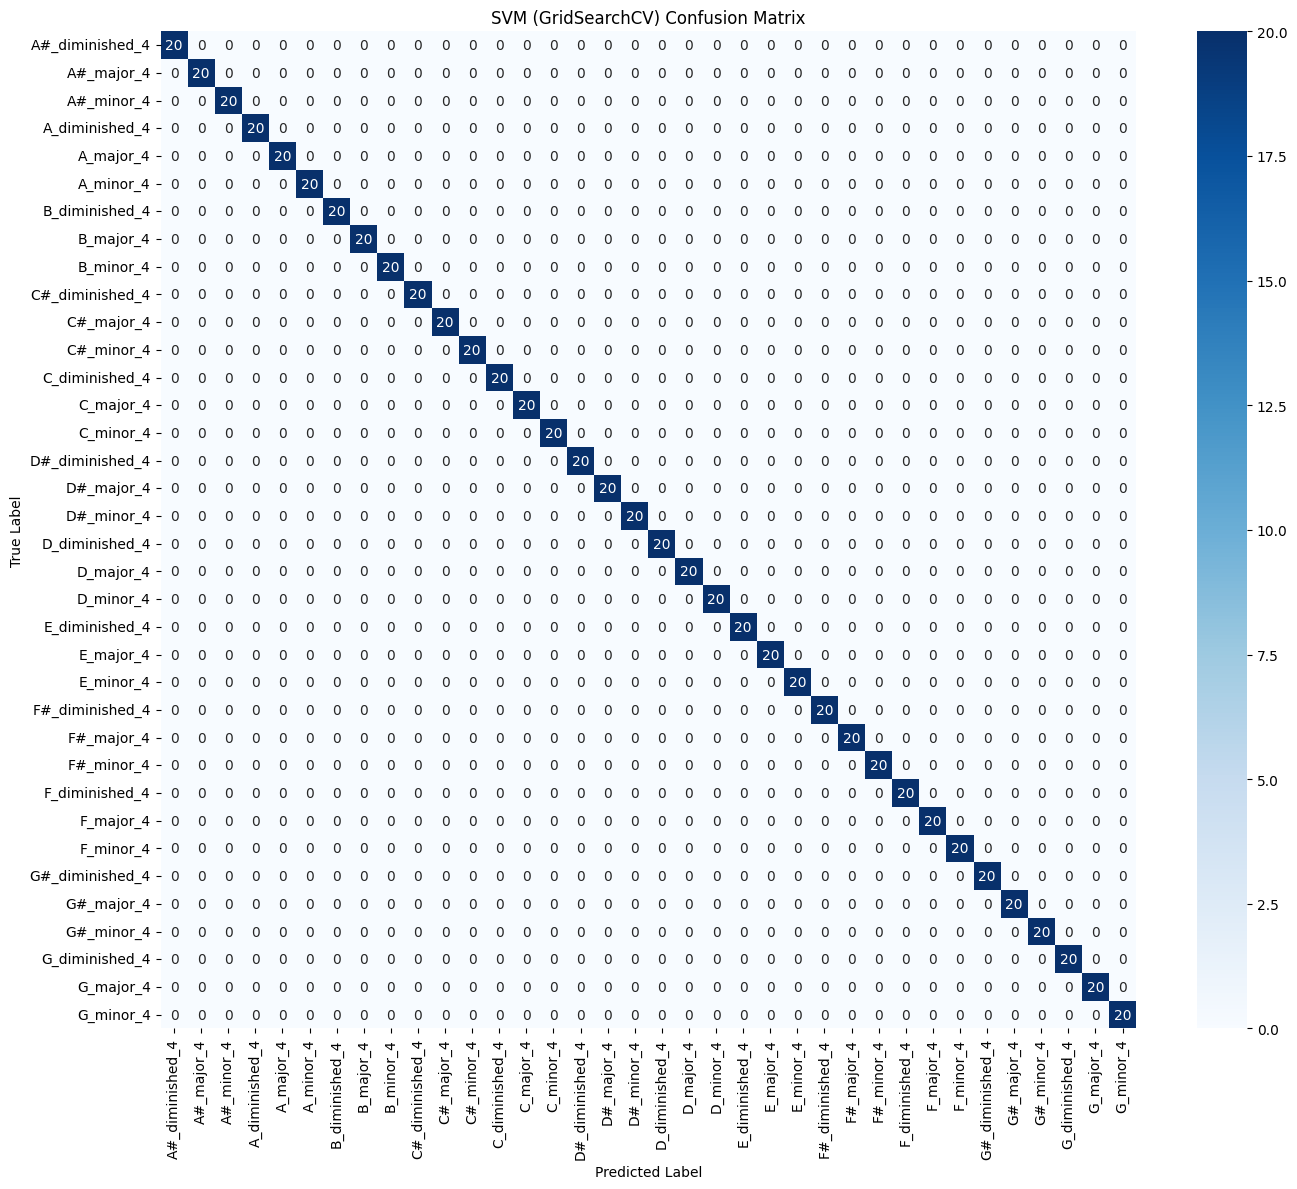

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert GPU objects to CPU NumPy arrays for compatibility with sklearn
y_test_cpu_cm = y_svm_test.to_numpy() if hasattr(y_svm_test, 'to_numpy') else np.array(y_svm_test)
y_pred_cpu_cm = y_gs_pred.get() if hasattr(y_gs_pred, 'get') else np.array(y_gs_pred)

cm_gs = confusion_matrix(y_test_cpu_cm, y_pred_cpu_cm)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_gs, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'SVM (GridSearchCV) Confusion Matrix')
plt.tight_layout()
plt.show()

## Save SVM Model

In [12]:
import joblib

joblib.dump(best_svm_model, SVM_MODEL_PATH)
joblib.dump(scaler, SVM_SCALER_PATH)
joblib.dump(svm_label_encoder, SVM_ENCODER_PATH)

print(f"SVM model saved to {MODEL_SAVE_PATH}")

SVM model saved to ./models


# Test Noisy

## Load Model & Noisy Features

In [17]:
import joblib

svm_model = joblib.load(SVM_MODEL_PATH)
svm_scaler = joblib.load(SVM_SCALER_PATH)
svm_label_encoder = joblib.load(SVM_ENCODER_PATH)
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print(f"SVM model loaded from {MODEL_SAVE_PATH}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models
Classes: Index(['A#_diminished_4', 'A#_major_4', 'A#_minor_4', 'A_diminished_4',
       'A_major_4', 'A_minor_4', 'B_diminished_4', 'B_major_4', 'B_minor_4',
       'C#_diminished_4', 'C#_major_4', 'C#_minor_4', 'C_diminished_4',
       'C_major_4', 'C_minor_4', 'D#_diminished_4', 'D#_major_4', 'D#_minor_4',
       'D_diminished_4', 'D_major_4', 'D_minor_4', 'E_diminished_4',
       'E_major_4', 'E_minor_4', 'F#_diminished_4', 'F#_major_4', 'F#_minor_4',
       'F_diminished_4', 'F_major_4', 'F_minor_4', 'G#_diminished_4',
       'G#_major_4', 'G#_minor_4', 'G_diminished_4', 'G_major_4', 'G_minor_4'],
      dtype='object')


## Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.6989

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.83      0.91       100
     A#_major_4       1.00      1.00      1.00       100
     A#_minor_4       1.00      1.00      1.00       100
 A_diminished_4       1.00      0.66      0.80       100
      A_major_4       0.99      0.99      0.99       100
      A_minor_4       0.74      0.99      0.85       100
 B_diminished_4       1.00      0.73      0.84       100
      B_major_4       1.00      0.59      0.74       100
      B_minor_4       1.00      0.76      0.86       100
C#_diminished_4       0.89      0.08      0.15       100
     C#_major_4       0.73      0.08      0.14       100
     C#_minor_4       0.83      0.10      0.18       100
 C_diminished_4       0.41      1.00      0.58       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4    

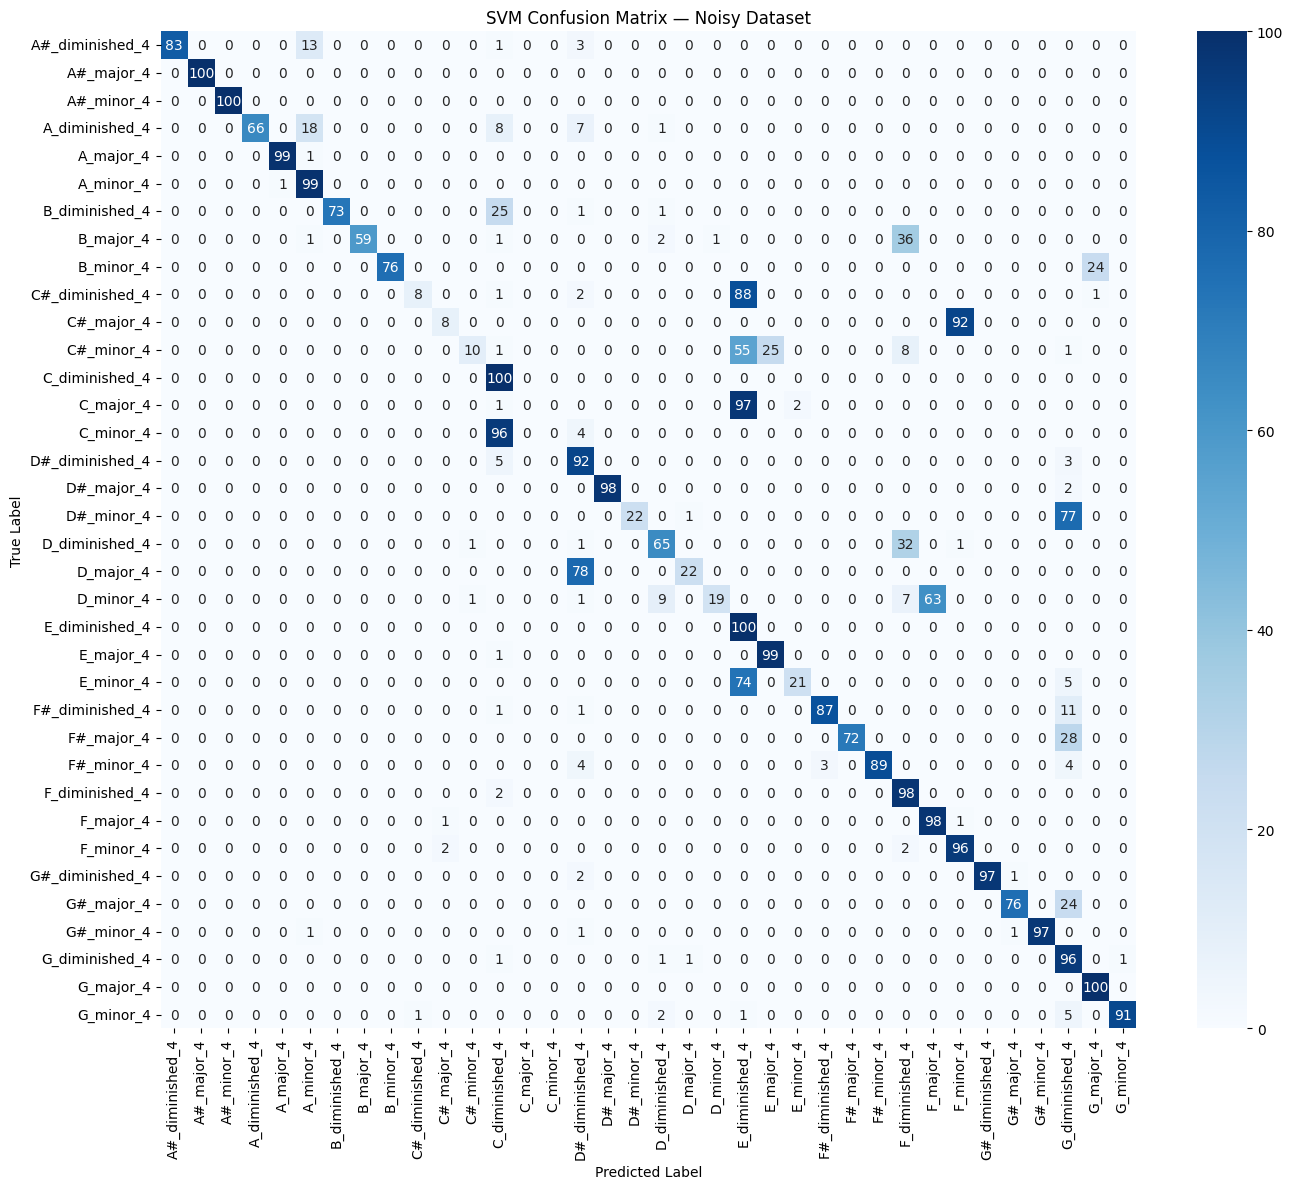

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Flatten and scale noisy features the same way as training data
noisy_features_flat = noisy_features.reshape(noisy_features.shape[0], -1)
# Use transform only (do not re-fit the scaler on test data)
noisy_features_scaled = svm_scaler.transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# --- FIX: Convert GPU objects to CPU NumPy arrays for sklearn compatibility ---
y_true_cpu = noisy_svm_encoded.to_numpy() if hasattr(noisy_svm_encoded, 'to_numpy') else np.array(noisy_svm_encoded)
y_pred_cpu = y_noisy_pred.get() if hasattr(y_noisy_pred, 'get') else np.array(y_noisy_pred)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(y_true_cpu, y_pred_cpu)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.4f}")

# Convert class labels to host list if necessary
svm_class_labels = svm_label_encoder.classes_.to_numpy() if hasattr(svm_label_encoder.classes_, 'to_numpy') else svm_label_encoder.classes_

report_noisy_svm = classification_report(y_true_cpu, y_pred_cpu, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(y_true_cpu, y_pred_cpu)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()